# 01 — Dataset overview (manual + simulated)

Loads **manual** and **simulated** CSVs, validates columns, summarises the target `wastage_label`, and plots room / time patterns.

Run from anywhere; the next cell `chdir`s to the repo root `smart-energy-optimizer/`.

In [2]:
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, *ROOT.parents]:
    if (candidate / "data" / "raw" / "manual_data.csv").is_file():
        os.chdir(candidate)
        break
else:
    raise FileNotFoundError("Could not find data/raw/manual_data.csv — open Jupyter from repo root or notebooks/")
print("CWD:", os.getcwd())

CWD: B:\PBCS\VI Sem\Machine Learning\MiniProject\Final\smart-energy-optimizer


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="husl")

manual = pd.read_csv("data/raw/manual_data.csv")
sim = pd.read_csv("data/simulated/virtual_iot_data.csv")

print("Manual shape:", manual.shape)
print("Simulated shape:", sim.shape)
print("\nManual columns:", list(manual.columns))
manual.head()

Manual shape: (250, 13)
Simulated shape: (1560, 13)

Manual columns: ['date', 'time_slot', 'room_id', 'occupancy', 'fan_status', 'light_status', 'ac_status', 'projector_status', 'power_consumption_w', 'day_of_week', 'is_break_period', 'is_after_hours', 'wastage_label']


,date,time_slot,room_id,occupancy,fan_status,light_status,ac_status,projector_status,power_consumption_w,day_of_week,is_break_period,is_after_hours,wastage_label
0,02-02-2026,2:00 PM,Class1,1,1,1,0,0,460,Monday,0,0,0
1,02-02-2026,3:00 PM,Lab1,1,1,1,0,0,460,Monday,0,0,0
2,02-02-2026,4:30 PM,Lab2,0,1,1,0,0,460,Monday,0,1,1
3,02-02-2026,4:30 PM,Class3,0,1,1,0,0,460,Monday,0,1,1
4,02-02-2026,9:00 AM,Lab2,0,0,0,0,0,0,Monday,0,0,0


In [4]:
for name, df in [("manual", manual), ("simulated", sim)]:
    print(f"\n=== {name} ===")
    print(df.describe(include="all").T.head(20))
    print("wastage_label mean:", df["wastage_label"].mean())


=== manual ===
                     count unique         top freq    mean         std  min  \
date                   250     56  11-03-2026   11     NaN         NaN  NaN   
time_slot              250     18     4:30 PM   21     NaN         NaN  NaN   
room_id                250      6      Class1   52     NaN         NaN  NaN   
occupancy            250.0    NaN         NaN  NaN   0.548    0.498689  0.0   
fan_status           250.0    NaN         NaN  NaN   0.744    0.437297  0.0   
light_status         250.0    NaN         NaN  NaN   0.744    0.437297  0.0   
ac_status            250.0    NaN         NaN  NaN     0.0         0.0  0.0   
projector_status     250.0    NaN         NaN  NaN   0.364    0.482114  0.0   
power_consumption_w  250.0    NaN         NaN  NaN  433.68  242.442511  0.0   
day_of_week            250      6   Wednesday   57     NaN         NaN  NaN   
is_break_period      250.0    NaN         NaN  NaN   0.248    0.432718  0.0   
is_after_hours       250.0    NaN   

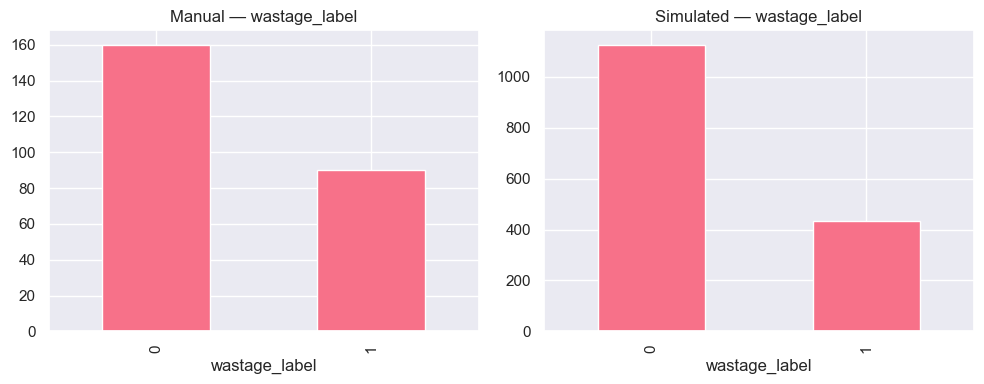

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
manual["wastage_label"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Manual — wastage_label")
sim["wastage_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Simulated — wastage_label")
plt.tight_layout()
plt.show()

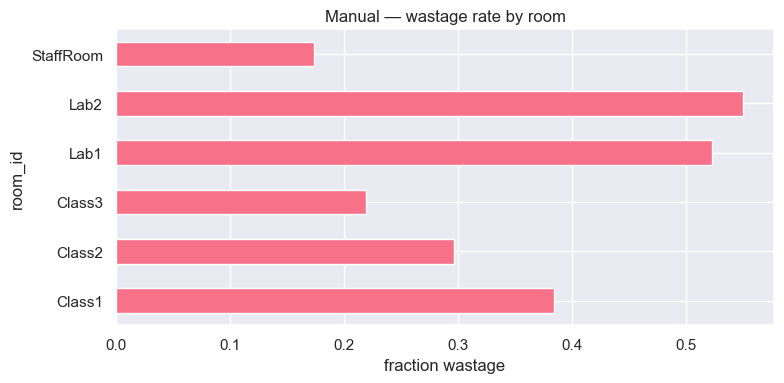

,sum,count,rate
room_id,,,
Class1,20,52,0.384615
Class2,8,27,0.296296
Class3,9,41,0.219512
Lab1,23,44,0.522727
Lab2,22,40,0.550000
StaffRoom,8,46,0.173913


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
room_counts = manual.groupby("room_id")["wastage_label"].agg(["sum", "count"])
room_counts["rate"] = room_counts["sum"] / room_counts["count"]
room_counts["rate"].plot(kind="barh", ax=ax, title="Manual — wastage rate by room")
plt.xlabel("fraction wastage")
plt.tight_layout()
plt.show()
room_counts